## 1. Understand the dataset

In [ ]:
import pandas as pd

DATA_DIR = "../dataset/fitzpatrick17k.csv"
# Load data
df = pd.read_csv(DATA_DIR)

In [3]:
df.shape # (16577 rows, 9 columns)

(16577, 9)

In [4]:
df.head()

,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


The Fitzpatrick scale served as the basis for skin color in emojis and, more recently, the Fitzpatrick scale has been used in computer vision applications to evaluate algorithmic fairness and model accuracy. The annotated images represent 114 skin conditions with at least 53 images and a maximum of 653 images per skin condition.

In [5]:
pd.set_option('display.max_rows', 120) # to see all of the labels
df['label'].value_counts(ascending=True)

label
pustular psoriasis                                        53
pilomatricoma                                             53
xanthomas                                                 53
erythema elevatum diutinum                                55
paronychia                                                59
port wine stain                                           59
livedo reticularis                                        60
disseminated actinic porokeratosis                        60
langerhans cell histiocytosis                             60
perioral dermatitis                                       61
basal cell carcinoma morpheiform                          62
behcets disease                                           63
becker nevus                                              63
ichthyosis vulgaris                                       65
sun damaged skin                                          66
solid cystic basal cell carcinoma                         66
factitial dermatit

In [6]:
df['nine_partition_label'].value_counts(ascending=True)

nine_partition_label
malignant dermal                  156
malignant cutaneous lymphoma      182
benign melanocyte                 236
malignant melanoma                573
benign epidermal                  931
benign dermal                    1067
genodermatoses                   1194
malignant epidermal              1352
inflammatory                    10886
Name: count, dtype: int64

- Non-Neoplastic : Not a tumor/new growth                   -> Normal
- Benign	     : Non-cancerous new growth (neoplasm) -> Neutral
- Malignant	     : Cancerous new growth (neoplasm).    -> Dangerous

In [7]:
df['three_partition_label'].value_counts(ascending=True)

three_partition_label
benign             2234
malignant          2263
non-neoplastic    12080
Name: count, dtype: int64

<Axes: xlabel='three_partition_label'>

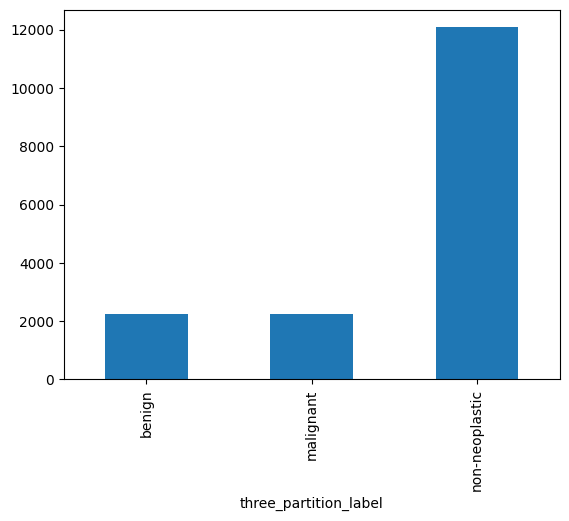

In [8]:
df['three_partition_label'].value_counts(ascending=True).plot(kind='bar')

- 1-2: Very light to light skin (Type I-II) - Burns easily, rarely tans
- 3-4: Medium skin (Type III-IV) - Tans gradually, sometimes burns
- 5-6: Dark to very dark skin (Type V-VI) - Tans easily, rarely burns
- -1: Unknown

In [9]:
df['fitzpatrick_scale'].value_counts().sort_index()

fitzpatrick_scale
-1     565
 1    2947
 2    4808
 3    3308
 4    2781
 5    1533
 6     635
Name: count, dtype: int64

<Axes: xlabel='fitzpatrick_scale'>

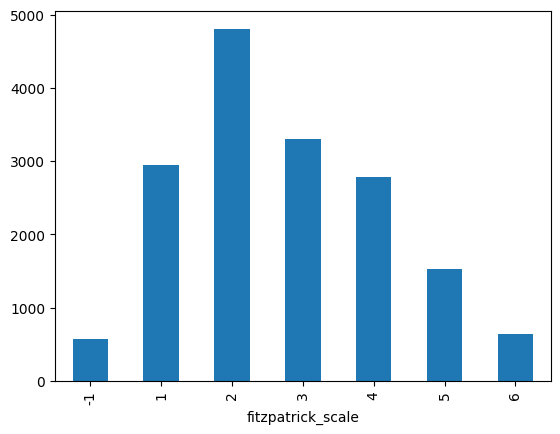

In [10]:
df['fitzpatrick_scale'].value_counts().sort_index().plot(kind='bar')

In [11]:
pd.crosstab(df['fitzpatrick_scale'], df['three_partition_label'], margins=True, margins_name='Total')

three_partition_label,benign,malignant,non-neoplastic,Total
fitzpatrick_scale,,,,
-1,74,103,388,565
1,444,453,2050,2947
2,671,742,3395,4808
3,475,456,2377,3308
4,367,301,2113,2781
5,159,147,1227,1533
6,44,61,530,635
Total,2234,2263,12080,16577


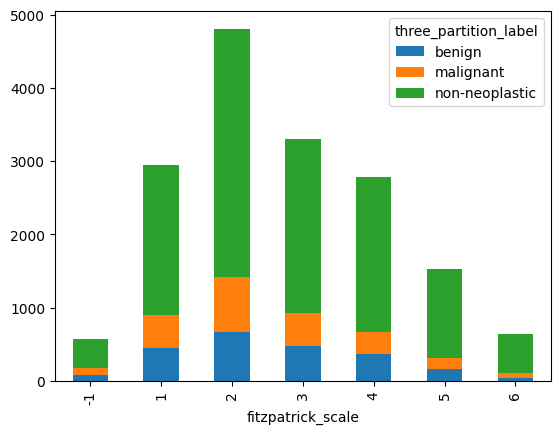

In [12]:
table = pd.crosstab(df['fitzpatrick_scale'], df['three_partition_label']).plot(kind='bar', stacked=True)\
    # calculate the percentage
    # why the value of 1 is less than we expect

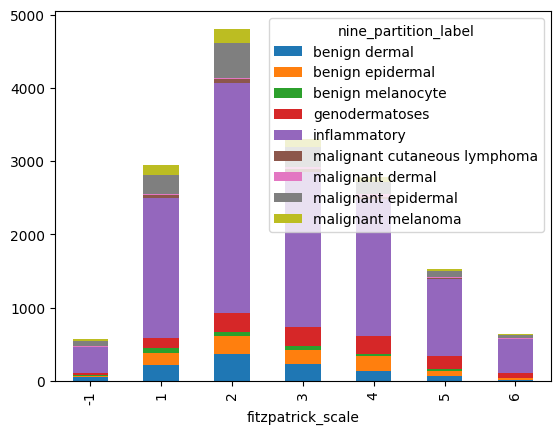

In [13]:
table = pd.crosstab(df['fitzpatrick_scale'], df['nine_partition_label']).plot(kind='bar', stacked=True)
# have the description of each labels

In [14]:
table = pd.crosstab(df['fitzpatrick_scale'], df['nine_partition_label'], margins=True, margins_name='Total')

In [15]:
table

nine_partition_label,benign dermal,benign epidermal,benign melanocyte,genodermatoses,inflammatory,malignant cutaneous lymphoma,malignant dermal,malignant epidermal,malignant melanoma,Total
fitzpatrick_scale,,,,,,,,,,
-1,49,22,3,29,359,6,5,65,27,565
1,216,160,68,143,1907,38,17,265,133,2947
2,364,247,60,261,3134,50,27,467,198,4808
3,225,202,48,266,2111,42,29,277,108,3308
4,136,198,33,251,1862,29,42,170,60,2781
5,60,81,18,182,1045,14,24,77,32,1533
6,17,21,6,62,468,3,12,31,15,635
Total,1067,931,236,1194,10886,182,156,1352,573,16577


In [17]:
grand_total = int(table['Total']['Total'])
table.sum()

nine_partition_label
benign dermal                    2134
benign epidermal                 1862
benign melanocyte                 472
genodermatoses                   2388
inflammatory                    21772
malignant cutaneous lymphoma      364
malignant dermal                  312
malignant epidermal              2704
malignant melanoma               1146
Total                           33154
dtype: int64

In [18]:
table.tail(1)

nine_partition_label,benign dermal,benign epidermal,benign melanocyte,genodermatoses,inflammatory,malignant cutaneous lymphoma,malignant dermal,malignant epidermal,malignant melanoma,Total
fitzpatrick_scale,,,,,,,,,,
Total,1067,931,236,1194,10886,182,156,1352,573,16577


## 2. Preprocess the data

Download the image from the URL

In [16]:
import requests 
import os
from tqdm import tqdm
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
# Create an images directory
df = pd.read_csv('../dataset/fitzpatrick17k.csv')
os.makedirs('../dataset/images', exist_ok=True)
data_dir = '../dataset/images'
def download_image(row):
    """Download a single image and save it using its md5hash as filename."""
    url = row['url']
    md5hash = row['md5hash']
    filepath = f'../dataset/images/{md5hash}.jpg'
    
    # Skip if already downloaded
    if os.path.exists(filepath):
        return md5hash, 'skipped'
    
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()  
        
        with open(filepath, 'wb') as f:
            f.write(response.content)
        return md5hash, 'success'
    
    except Exception as e:
        return md5hash, f'failed: {str(e)}'
def download_all_images(df, max_workers=10):
    """Download images in parallel using ThreadPoolExecutor."""
    results = {'success': 0, 'failed': 0, 'skipped': 0}
    failed_urls = []
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(download_image, row): row['md5hash'] 
                   for _, row in df.iterrows()}
        
        for future in tqdm(as_completed(futures), total=len(futures)):
            md5hash, status = future.result()
            if status == 'success':
                results['success'] += 1
            elif status == 'skipped':
                results['skipped'] += 1
            else:
                results['failed'] += 1
                failed_urls.append((md5hash, status))
    
    print(f"Downloaded: {results['success']}")
    print(f"Skipped (already exists): {results['skipped']}")
    print(f"Failed: {results['failed']}")
    
    return failed_urls

failed = download_all_images(df, max_workers=300)
print(failed)

    
    


100%|██████████| 16577/16577 [00:00<00:00, 20221.48it/s] 

Downloaded: 0
Skipped (already exists): 16518
Failed: 59
[('8cfe54501fe00ddc74096b7cd67aa1e1', "failed: Invalid URL 'nan': No scheme supplied. Perhaps you meant https://nan?"), ('acbc68bd9e35591b8344ab8b5e51f458', "failed: Invalid URL 'nan': No scheme supplied. Perhaps you meant https://nan?"), ('28126ac3ed45c0f1f282baa0c04232cd', "failed: Invalid URL 'nan': No scheme supplied. Perhaps you meant https://nan?"), ('6712381a925124e968bcac89481c90e0', "failed: Invalid URL 'nan': No scheme supplied. Perhaps you meant https://nan?"), ('d653edb6aa702f095a9b00550738a821', "failed: Invalid URL 'nan': No scheme supplied. Perhaps you meant https://nan?"), ('2ed97fd85d7c7f94523d60fa1e3c3dfc', "failed: Invalid URL 'nan': No scheme supplied. Perhaps you meant https://nan?"), ('f0e1f501ec5f67e5ce9486a59304b4ab', "failed: Invalid URL 'nan': No scheme supplied. Perhaps you meant https://nan?"), ('267e230db9a29ddc9fb4c3b7a394a055', "failed: Invalid URL 'nan': No scheme supplied. Perhaps you meant https:

In [3]:
df.head()

,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


In [17]:
failed = [md5hash for md5hash, _ in failed]
df_clean = df[~df['md5hash'].isin(failed)]

print(f"Original dataset: {len(df)} rows")
print(f"Removed: {len(failed)} rows with failed downloads")
print(f"Clean dataset: {len(df_clean)} rows")

# Save the cleaned dataset
df_clean.to_csv('../dataset/fitzpatrick17k_clean.csv', index=False)
print("\nSaved cleaned dataset to '../dataset/fitzpatrick17k_clean.csv'")

Original dataset: 16577 rows
Removed: 59 rows with failed downloads
Clean dataset: 16518 rows

Saved cleaned dataset to '../dataset/fitzpatrick17k_clean.csv'


In [20]:
import os
path = "../dataset/images"
def count_files(path):
    count = 0
    with os.scandir(path) as it:
        for entry in it:
            if entry.is_file():
                count += 1
    return count

print(f"File count: {count_files('../dataset/images')}")

File count: 16518


In [24]:
df.head()

,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


In [26]:
df = pd.read_csv("../dataset/fitzpatrick17k_clean.csv")
df = df.drop(['qc','url','url_alphanum'], axis=1)
df.to_csv('../dataset/fitzpatrick17k_clean.csv', index=False)


In [28]:
df = pd.read_csv("../dataset/fitzpatrick17k_clean.csv")
df.head()

,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic


In [ ]:
df_clean = pd.read_csv("../dataset/fitzpatrick17k_clean.csv")
df_clean = df_clean.drop(['fitzpatrick_centaur', 'label','nine_partition_label'], axis=1)
print('Dropped')
df_clean.to_csv('../dataset/fitzpatrick17k_cleaned.csv', index=False)


Dropped


In [45]:

df_clean = pd.read_csv("../dataset/fitzpatrick17k_cleaned.csv")
df_clean = df_clean[df_clean['fitzpatrick_scale'] != -1]
df_clean.to_csv('../dataset/fitzpatrick17k_cleaned.csv', index=False)


In [50]:
df_clean['fitzpatrick_scale'].value_counts().sort_index()

fitzpatrick_scale
1    2941
2    4795
3    3294
4    2771
5    1527
6     628
Name: count, dtype: int64

Start with the conditional GAN. Nam lead that

In [51]:
df_clean.head()

,md5hash,fitzpatrick_scale,three_partition_label
0,5e82a45bc5d78bd24ae9202d194423f8,3,non-neoplastic
1,fa2911a9b13b6f8af79cb700937cc14f,1,non-neoplastic
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,benign
3,0a94359e7eaacd7178e06b2823777789,1,non-neoplastic
4,a39ec3b1f22c08a421fa20535e037bba,1,non-neoplastic
